<a href="https://colab.research.google.com/github/AbdulrahmanB-25/Machine_Learning_Competition/blob/main/ML_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/refs/heads/main/Riyadh_Master_Dataset.csv'

# Load the dataset
df = pd.read_csv(url)

# Preview the data
df.head()

,neighborhood,property_id,price,area,category,total_rooms,lat,lng,dining_cafe,med_facilities,...,pedestrian,resort_rural_retreats,gov_civil,malls_shopping,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score,bus_count,metro_count
0,2nd Industrial City,1,4500.0,160.0,1,6,24.557812,46.862682,46,2,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
1,2nd Industrial City,2,17000.0,150.0,1,4,24.548426,46.866436,46,2,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
2,2nd Industrial City,3,1500000.0,750.0,2,0,24.555798,46.860222,46,2,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
3,2nd Industrial City,4,1000000.0,600.0,2,0,24.557178,46.864990,46,2,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
4,2nd Industrial City,5,1200000.0,600.0,2,0,24.554862,46.861086,46,2,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0


In [2]:
print(df.shape)

(348704, 28)


In [3]:
print(df.columns.tolist())

['neighborhood', 'property_id', 'price', 'area', 'category', 'total_rooms', 'lat', 'lng', 'dining_cafe', 'med_facilities', 'health_retail', 'fitness_care', 'edu_primary', 'edu_higher', 'religious', 'essential_retail', 'parks_green', 'sports_play', 'pedestrian', 'resort_rural_retreats', 'gov_civil', 'malls_shopping', 'Fiber_Available', 'FWA_Available', 'Mobile_Available', 'connectivity_score', 'bus_count', 'metro_count']


In [4]:
# keep only numeric columns
df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric.head()

,property_id,price,area,category,total_rooms,lat,lng,dining_cafe,med_facilities,health_retail,...,pedestrian,resort_rural_retreats,gov_civil,malls_shopping,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score,bus_count,metro_count
0,1,4500.0,160.0,1,6,24.557812,46.862682,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
1,2,17000.0,150.0,1,4,24.548426,46.866436,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
2,3,1500000.0,750.0,2,0,24.555798,46.860222,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
3,4,1000000.0,600.0,2,0,24.557178,46.864990,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
4,5,1200000.0,600.0,2,0,24.554862,46.861086,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0


In [5]:
# drop columns that should not be used in PCA
cols_to_drop = ["property_id"]  # ID column, not useful
df_numeric = df_numeric.drop(columns=cols_to_drop, errors="ignore")

# check missing values
print(df_numeric.isnull().sum())

price                      0
area                       0
category                   0
total_rooms                0
lat                        0
lng                        0
dining_cafe                0
med_facilities             0
health_retail              0
fitness_care               0
edu_primary                0
edu_higher                 0
religious                  0
essential_retail           0
parks_green                0
sports_play                0
pedestrian                 0
resort_rural_retreats      0
gov_civil                  0
malls_shopping             0
Fiber_Available          131
FWA_Available            131
Mobile_Available         131
connectivity_score       131
bus_count                  0
metro_count                0
dtype: int64


In [6]:
# fill with mean
df_numeric = df_numeric.fillna(df_numeric.mean())

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_numeric)

print(X_scaled.shape)

(348704, 26)


In [8]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# explained variance
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[2.59805588e-01 1.84461968e-01 8.40939029e-02 7.32482304e-02
 5.52560339e-02 5.32291323e-02 4.11944258e-02 3.84066435e-02
 3.44986700e-02 3.14628149e-02 2.94963989e-02 2.52831494e-02
 1.83743832e-02 1.44858896e-02 1.22893560e-02 1.15692801e-02
 9.06910548e-03 6.60308904e-03 5.58047720e-03 4.33424006e-03
 3.56158693e-03 1.78875344e-03 1.40909133e-03 4.97789668e-04
 7.00698591e-16 1.27643568e-19]


In [9]:
import numpy as np

cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.25980559 0.44426756 0.52836146 0.60160969 0.65686572 0.71009486
 0.75128928 0.78969592 0.82419459 0.85565741 0.88515381 0.91043696
 0.92881134 0.94329723 0.95558659 0.96715587 0.97622497 0.98282806
 0.98840854 0.99274278 0.99630437 0.99809312 0.99950221 1.
 1.         1.        ]


In [10]:
pca = PCA(n_components=13)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(348704, 13)


In [11]:
pca_columns = [f"PC{i+1}" for i in range(13)]

df_pca = pd.DataFrame(X_pca, columns=pca_columns)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-2.067698,-0.539126,0.578432,-1.854939,1.616348,0.666552,0.803567,-0.370001,2.399322,-0.445492,1.335824,-0.552685,0.838388
1,-2.098822,-0.544781,0.567941,-1.764010,1.618347,0.740054,0.660310,-0.169306,2.538838,-0.267581,1.393674,-0.542749,0.813380
2,-2.200792,-0.407945,0.318290,0.631162,1.310842,1.595412,1.554299,0.506753,2.731099,-0.092551,1.560065,-0.372842,1.187387
3,-2.195449,-0.436573,0.385934,0.040971,1.421892,1.425910,1.226616,0.490727,2.746150,-0.054067,1.546623,-0.399876,1.083231
4,-2.186659,-0.436344,0.376606,0.113964,1.392177,1.427557,1.279139,0.475540,2.713567,-0.069096,1.528100,-0.430542,1.065110


In [12]:
# remove neighborhood to prevent data leakage
df_numeric = df.select_dtypes(include=["int64", "float64"])

In [13]:
# Drop leakage / non-useful columns first
cols_to_drop = ["property_id", "neighborhood"]  # add neighborhood here

df_clean = df.drop(columns=cols_to_drop, errors="ignore")

# keep only numeric columns
df_numeric = df_clean.select_dtypes(include=["int64", "float64"])

df_numeric.head()

,price,area,category,total_rooms,lat,lng,dining_cafe,med_facilities,health_retail,fitness_care,...,pedestrian,resort_rural_retreats,gov_civil,malls_shopping,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score,bus_count,metro_count
0,4500.0,160.0,1,6,24.557812,46.862682,46,2,1,0,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
1,17000.0,150.0,1,4,24.548426,46.866436,46,2,1,0,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
2,1500000.0,750.0,2,0,24.555798,46.860222,46,2,1,0,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
3,1000000.0,600.0,2,0,24.557178,46.864990,46,2,1,0,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
4,1200000.0,600.0,2,0,24.554862,46.861086,46,2,1,0,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0


In [14]:
# Add k-means after PCA
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_pca)

df_pca["Cluster"] = clusters

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,Cluster
0,-2.067698,-0.539126,0.578432,-1.854939,1.616348,0.666552,0.803567,-0.370001,2.399322,-0.445492,1.335824,-0.552685,0.838388,1
1,-2.098822,-0.544781,0.567941,-1.764010,1.618347,0.740054,0.660310,-0.169306,2.538838,-0.267581,1.393674,-0.542749,0.813380,1
2,-2.200792,-0.407945,0.318290,0.631162,1.310842,1.595412,1.554299,0.506753,2.731099,-0.092551,1.560065,-0.372842,1.187387,1
3,-2.195449,-0.436573,0.385934,0.040971,1.421892,1.425910,1.226616,0.490727,2.746150,-0.054067,1.546623,-0.399876,1.083231,1
4,-2.186659,-0.436344,0.376606,0.113964,1.392177,1.427557,1.279139,0.475540,2.713567,-0.069096,1.528100,-0.430542,1.065110,1


In [15]:
df_pca["Cluster"].value_counts()

,count
Cluster,
2,143895
1,125781
0,79028


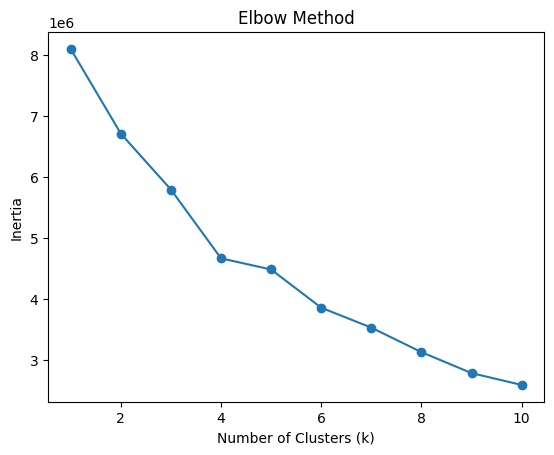

In [16]:
# Elbow method
import matplotlib.pyplot as plt

inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [17]:
best_k = 3  # <-- change based on your plots

kmeans = KMeans(n_clusters=best_k, random_state=42)
df_pca["Cluster"] = kmeans.fit_predict(X_pca)

In [19]:
# Umap for all the data but this cell did not run
import umap
import matplotlib.pyplot as plt
import seaborn as sns

reducer = umap.UMAP(n_neighbors=30,
                   min_dist=0.1,
                   n_components=2,
                   metric='euclidean',
                   random_state=42)

print("Starting UMAP... This might take a few minutes for 345k rows.")
umap_embedding = reducer.fit_transform(df_pca)
print("UMAP Completed!")

plt.figure(figsize=(14, 10))

import numpy as np
color_data = np.log1p(df['price'])

scatter = plt.scatter(umap_embedding[:, 0],
            umap_embedding[:, 1],
            c=color_data,
            cmap='viridis',
            s=0.05,
            alpha=0.3,
            edgecolors='none')

plt.colorbar(scatter, label='Log of Price')
plt.title('Riyadh Real Estate - UMAP Visualization (PCA 13 Input)', fontsize=16)
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')
plt.grid(False)
plt.show()

Starting UMAP... This might take a few minutes for 345k rows.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

Starting UMAP on 30000 properties... Please wait.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


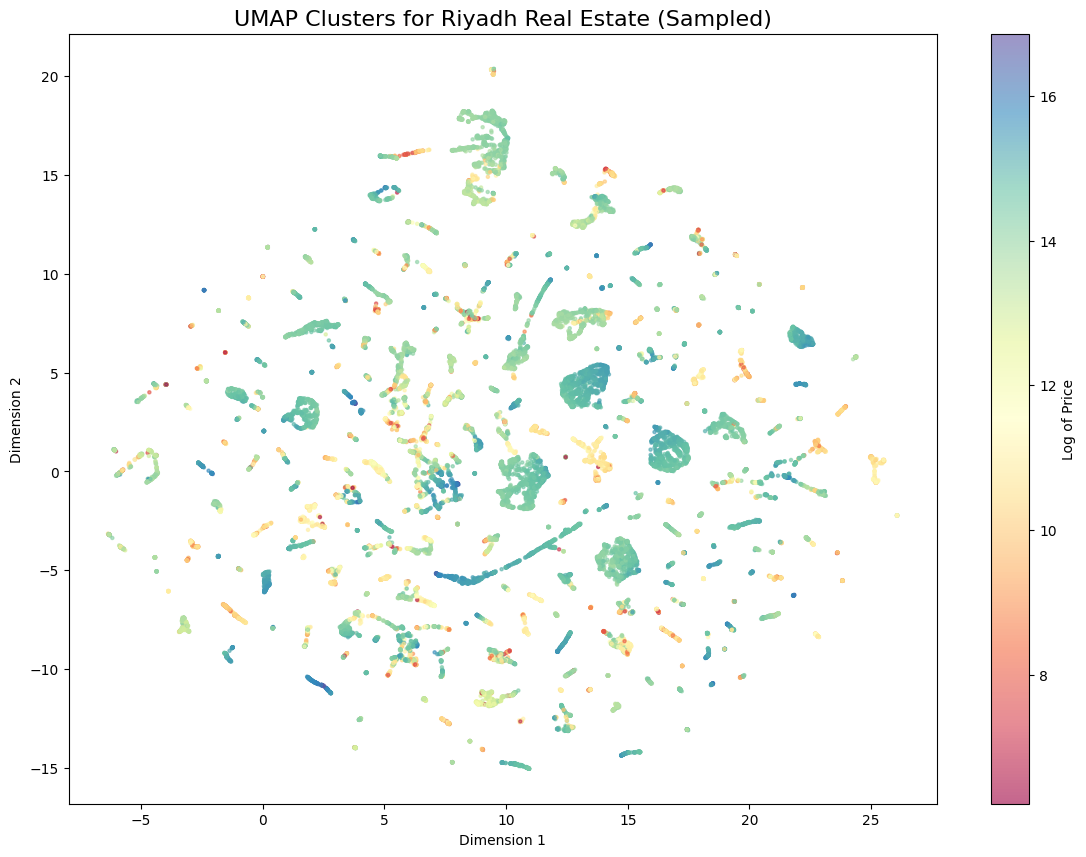

Done! You can now see how the properties are clustered.


In [21]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# only 30000 because the above cell did not run
sample_size = 30000
if len(df_pca) > sample_size:
    pca_sample = df_pca.sample(n=sample_size, random_state=42)
    df_sample = df.loc[pca_sample.index]
else:
    pca_sample = df_pca
    df_sample = df

print(f"Starting UMAP on {sample_size} properties... Please wait.")

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = reducer.fit_transform(pca_sample)

plt.figure(figsize=(14, 10))

color_data = np.log1p(df_sample['price'])

scatter = plt.scatter(umap_embedding[:, 0],
                      umap_embedding[:, 1],
                      c=color_data,
                      cmap='Spectral',
                      s=5,
                      alpha=0.6)

plt.colorbar(scatter, label='Log of Price')
plt.title('UMAP Clusters for Riyadh Real Estate (Sampled)', fontsize=16)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

print("Done! You can now see how the properties are clustered.")

In [24]:

threshold = df_sample['price'].quantile(0.95)

high_value_properties = df_sample[df_sample['price'] >= threshold]

#
print(" (Top 5%):")
print(high_value_properties['neighborhood'].value_counts().head(10))

low_threshold = df_sample['price'].quantile(0.10)
low_value_properties = df_sample[df_sample['price'] <= low_threshold]

print("\ (Bottom 10%):")
print(low_value_properties['neighborhood'].value_counts().head(10))

 (Top 5%):
neighborhood
Al Malqa Dist.       292
Al Narjis Dist.      281
Al Arid Dist.        104
Al Qairawan Dist.    101
Al Aqeeq Dist.        83
Hiteen Dist.          65
Al Yasmeen Dist.      54
Al Sahafah Dist.      45
Al Nada Dist.         32
Al Nakheel Dist.      25
Name: count, dtype: int64
\ (Bottom 10%):
neighborhood
Al Rimal Dist.         206
Al Arid Dist.          167
Al Yarmuk Dist.        167
Al Munisiyah Dist.     143
Dhahrat Laban Dist.    127
Al Malqa Dist.         123
Al Narjis Dist.        116
Ishbiliyah Dist.       112
Tuwaiq Dist.            98
Al Aqeeq Dist.          85
Name: count, dtype: int64


<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1073/2812979188.py:12: SyntaxWarning: invalid escape sequence '\ '
  print("\ (Bottom 10%):")
